# Week 3: N-gram Language Models and Autocomplete


## NLP Specialization - Course 2

This notebook provides hands-on implementation of N-gram language models for building autocomplete systems, complementing the theoretical concepts from your Week 3 notes.

---

## 1. Setup and Imports

Import necessary libraries for implementing N-gram language models. We'll use collections for efficient counting, numpy for numerical operations, and random for text generation.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
import random
import math
import string

# Set random seed for reproducibility
np.random.seed(42)
random.seed(42)

plt.style.use('seaborn-v0_8-darkgrid')

print("Libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

Libraries imported successfully!
NumPy version: 2.1.3
Pandas version: 2.3.3


## 2. Introduction to N-grams

N-grams are contiguous sequences of N words from text. They form the foundation of statistical language modeling and power autocomplete systems.

This corresponds to Section 2 of your notes - understanding what N-grams are and how they capture language patterns.


In [3]:
# Sample text for demonstrating N-grams
sample_text = "I am happy because I am learning"

print("N-gram Extraction Examples:")
print(f"\nOriginal text: '{sample_text}'")
print()

# Tokenize
words = sample_text.split()
print(f"Tokens: {words}")
print(f"Total tokens: {len(words)}")

N-gram Extraction Examples:

Original text: 'I am happy because I am learning'

Tokens: ['I', 'am', 'happy', 'because', 'I', 'am', 'learning']
Total tokens: 7


In [4]:
def extract_ngrams(words, n):
    """
    Extract all n-grams from a list of words.

    Args:
        words: list of tokens
        n: size of n-gram (1=unigram, 2=bigram, 3=trigram, etc.)

    Returns:
        list of n-gram tuples
    """
    ngrams = []
    for i in range(len(words) - n + 1):
        ngram = tuple(words[i:i+n])
        ngrams.append(ngram)
    return ngrams

# Extract different n-grams
unigrams = extract_ngrams(words, 1)
bigrams = extract_ngrams(words, 2)
trigrams = extract_ngrams(words, 3)
fourgrams = extract_ngrams(words, 4)

print("\nN-gram Extraction:")
print("-" * 70)
print(f"\nUnigrams (1-grams): {len(unigrams)}")
print(f"  {unigrams[:10]}")

print(f"\nBigrams (2-grams): {len(bigrams)}")
print(f"  {bigrams}")

print(f"\nTrigrams (3-grams): {len(trigrams)}")
print(f"  {trigrams}")

print(f"\nFourgrams (4-grams): {len(fourgrams)}")
print(f"  {fourgrams}")



N-gram Extraction:
----------------------------------------------------------------------

Unigrams (1-grams): 7
  [('I',), ('am',), ('happy',), ('because',), ('I',), ('am',), ('learning',)]

Bigrams (2-grams): 6
  [('I', 'am'), ('am', 'happy'), ('happy', 'because'), ('because', 'I'), ('I', 'am'), ('am', 'learning')]

Trigrams (3-grams): 5
  [('I', 'am', 'happy'), ('am', 'happy', 'because'), ('happy', 'because', 'I'), ('because', 'I', 'am'), ('I', 'am', 'learning')]

Fourgrams (4-grams): 4
  [('I', 'am', 'happy', 'because'), ('am', 'happy', 'because', 'I'), ('happy', 'because', 'I', 'am'), ('because', 'I', 'am', 'learning')]


In [5]:
# Count N-gram frequencies
def count_ngrams(ngrams):
    """Count frequency of each n-gram"""
    return Counter(ngrams)

unigram_counts = count_ngrams(unigrams)
bigram_counts = count_ngrams(bigrams)

print("\nN-gram Frequency Counts:")
print("=" * 70)

print("\nUnigram counts:")
for ngram, count in unigram_counts.most_common():
    print(f"  {ngram}: {count}")

print("\nBigram counts:")
for ngram, count in bigram_counts.most_common():
    print(f"  {ngram}: {count}")


N-gram Frequency Counts:

Unigram counts:
  ('I',): 2
  ('am',): 2
  ('happy',): 1
  ('because',): 1
  ('learning',): 1

Bigram counts:
  ('I', 'am'): 2
  ('am', 'happy'): 1
  ('happy', 'because'): 1
  ('because', 'I'): 1
  ('am', 'learning'): 1


## 3. Calculating N-gram Probabilities

The core of language modeling is calculating probabilities. This is Section 3 of your notes - the mathematical foundation of N-grams.

**Formula for bigram probability:**
P(w*i | w*{i-1}) = Count(w*{i-1}, w_i) / Count(w*{i-1})


In [6]:
def calculate_bigram_probability(bigram, bigram_counts, unigram_counts):
    """
    Calculate P(word2 | word1) using Maximum Likelihood Estimation.

    Formula: P(w2|w1) = Count(w1, w2) / Count(w1)
    """
    word1, word2 = bigram

    bigram_count = bigram_counts.get(bigram, 0)
    unigram_count = unigram_counts.get((word1,), 0)

    if unigram_count == 0:
        return 0

    probability = bigram_count / unigram_count
    return probability

# Calculate some bigram probabilities
print("Bigram Probability Examples:")
print("=" * 70)

test_bigrams = [("I", "am"), ("am", "happy"), ("am", "learning"), ("I", "learning")]

for bigram in test_bigrams:
    prob = calculate_bigram_probability(bigram, bigram_counts, unigram_counts)
    print(f"P('{bigram[1]}' | '{bigram[0]}') = {prob:.4f}")

Bigram Probability Examples:
P('am' | 'I') = 1.0000
P('happy' | 'am') = 0.5000
P('learning' | 'am') = 0.5000
P('learning' | 'I') = 0.0000


In [7]:
def build_probability_matrix(bigram_counts, unigram_counts):
    """
    Build a probability matrix for all bigrams.
    Returns a nested dictionary: {word1: {word2: probability}}
    """
    prob_matrix = defaultdict(dict)

    for (word1, word2), count in bigram_counts.items():
        unigram_count = unigram_counts[(word1,)]
        prob_matrix[word1][word2] = count / unigram_count

    return dict(prob_matrix)

# Build probability matrix
prob_matrix = build_probability_matrix(bigram_counts, unigram_counts)

print("\nComplete Probability Matrix:")

for word1 in sorted(prob_matrix.keys()):
    print(f"\nP(word | '{word1}'):")
    for word2, prob in sorted(prob_matrix[word1].items(), key=lambda x: x[1], reverse=True):
        print(f"  {word2}: {prob:.4f}")


Complete Probability Matrix:

P(word | 'I'):
  am: 1.0000

P(word | 'am'):
  happy: 0.5000
  learning: 0.5000

P(word | 'because'):
  I: 1.0000

P(word | 'happy'):
  because: 1.0000


## 4. Sentence Probability with Chain Rule

Calculate the probability of an entire sentence using the chain rule of probability. This is Section 4 of your notes - sequence probabilities.

**Chain Rule (bigram approximation):**
P(w1, w2, ..., wn) ≈ P(w1) × P(w2|w1) × P(w3|w2) × ... × P(wn|w\_{n-1})


In [8]:
def calculate_sentence_probability(sentence, prob_matrix, start_prob=None):
    """
    Calculate the probability of a sentence using bigram model.

    Args:
        sentence: string of words
        prob_matrix: probability matrix from bigrams
        start_prob: initial word probabilities (optional)

    Returns:
        probability of the sentence
    """
    words = sentence.split()

    if len(words) == 0:
        return 0

    probability = 1.0

    # For first word (can use uniform or specific start probability)
    if start_prob and words[0] in start_prob:
        probability *= start_prob[words[0]]

    # Calculate conditional probabilities for remaining words
    for i in range(len(words) - 1):
        word1 = words[i]
        word2 = words[i + 1]

        if word1 in prob_matrix and word2 in prob_matrix[word1]:
            prob = prob_matrix[word1][word2]
            probability *= prob
        else:
            # Unseen bigram
            return 0

    return probability

# Test sentence probabilities
print("Sentence Probability Calculation:")

test_sentences = [
    "I am happy",
    "I am learning",
    "am I happy",
    "happy I am",
]

for sentence in test_sentences:
    prob = calculate_sentence_probability(sentence, prob_matrix)
    print(f"P('{sentence}') = {prob:.6f}")


Sentence Probability Calculation:
P('I am happy') = 0.500000
P('I am learning') = 0.500000
P('am I happy') = 0.000000
P('happy I am') = 0.000000


## 5. Handling Sentence Boundaries

Add special start and end tokens to properly handle sentence beginnings and endings. This is Section 5 of your notes - critical for proper probability calculations.

**Key Rules:**

- Add (N-1) start tokens for N-gram model
- Add exactly 1 end token


In [10]:
def add_sentence_boundaries(sentence, n=2):
    """
    Add start and end tokens to a sentence.

    For N-gram model:
    - Add (N-1) <s> tokens at the start
    - Add 1 </s> token at the end

    Args:
        sentence: input sentence string
        n: n-gram order (2 for bigram, 3 for trigram, etc.)

    Returns:
        processed sentence with boundary tokens
    """
    start_tokens = "<s> " * (n - 1)
    end_token = " </s>"

    return start_tokens + sentence + end_token

# Demonstrate boundary tokens
print("Sentence Boundary Tokens:")
print("-" * 70)

original = "I am learning"

print(f"\nOriginal: '{original}'")
print(f"Bigram (n=2):   '{add_sentence_boundaries(original, n=2)}'")
print(f"Trigram (n=3):  '{add_sentence_boundaries(original, n=3)}'")
print(f"4-gram (n=4):   '{add_sentence_boundaries(original, n=4)}'")

Sentence Boundary Tokens:
----------------------------------------------------------------------

Original: 'I am learning'
Bigram (n=2):   '<s> I am learning </s>'
Trigram (n=3):  '<s> <s> I am learning </s>'
4-gram (n=4):   '<s> <s> <s> I am learning </s>'


In [12]:
# Build corpus with boundary tokens
corpus_sentences = [
    "I love machine learning",
    "I learn deep learning",
    "Machine learning is fun",
    "Deep learning is amazing",
    "I study natural language processing",
]

print("\nProcessing Corpus with Boundaries:")
print("-" * 70)

# Process for bigram model
processed_corpus = [add_sentence_boundaries(sent, n=2) for sent in corpus_sentences]

for i, (original, processed) in enumerate(zip(corpus_sentences, processed_corpus), 1):
    print(f"\n{i}. Original:  {original}")
    print(f"   Processed: {processed}")


Processing Corpus with Boundaries:
----------------------------------------------------------------------

1. Original:  I love machine learning
   Processed: <s> I love machine learning </s>

2. Original:  I learn deep learning
   Processed: <s> I learn deep learning </s>

3. Original:  Machine learning is fun
   Processed: <s> Machine learning is fun </s>

4. Original:  Deep learning is amazing
   Processed: <s> Deep learning is amazing </s>

5. Original:  I study natural language processing
   Processed: <s> I study natural language processing </s>


## 6. Building Complete N-gram Language Model

Now let's build a complete language model from a corpus. This is Section 6 of your notes - the complete implementation.


In [14]:
class NgramLanguageModel:
    """
    Complete N-gram Language Model implementation.

    Features:
    - Count matrix construction
    - Probability matrix generation
    - Sentence probability calculation
    - Next word prediction
    - Text generation
    """

    def __init__(self, n=2):
        self.n = n
        self.ngram_counts = defaultdict(lambda: defaultdict(int))
        self.context_counts = defaultdict(int)
        self.vocabulary = set()

    def train(self, corpus_sentences):
        """
        Train the model on a corpus of sentences.

        Args:
            corpus_sentences: list of sentence strings
        """
        print(f"Training {self.n}-gram model...")

        for sentence in corpus_sentences:
            # Add boundary tokens
            processed = add_sentence_boundaries(sentence, self.n)
            words = processed.split()

            # Add to vocabulary
            self.vocabulary.update(words)

            # Extract n-grams and count
            for i in range(len(words) - self.n + 1):
                # Context: first (n-1) words
                context = tuple(words[i:i+self.n-1])
                # Target: last word
                target = words[i+self.n-1]

                # Update counts
                self.ngram_counts[context][target] += 1
                self.context_counts[context] += 1

        print(f"  Vocabulary size: {len(self.vocabulary)}")
        print(f"  Unique contexts: {len(self.context_counts)}")
        print(f"  Total n-grams: {sum(self.context_counts.values())}")

    def get_probability(self, context, word):
        """
        Get P(word | context) using Maximum Likelihood Estimation.

        Args:
            context: tuple of (n-1) previous words
            word: target word

        Returns:
            conditional probability
        """
        if not isinstance(context, tuple):
            context = tuple(context.split())

        if context not in self.context_counts:
            return 0

        ngram_count = self.ngram_counts[context].get(word, 0)
        context_count = self.context_counts[context]

        return ngram_count / context_count

    def sentence_probability(self, sentence):
        """
        Calculate probability of a sentence.

        Args:
            sentence: input sentence (with boundary tokens)

        Returns:
            sentence probability
        """
        words = sentence.split()
        probability = 1.0

        for i in range(len(words) - self.n + 1):
            context = tuple(words[i:i+self.n-1])
            target = words[i+self.n-1]

            prob = self.get_probability(context, target)
            if prob == 0:
                return 0

            probability *= prob

        return probability

    def predict_next_word(self, context, top_k=5):
        """
        Predict most likely next words given context.

        Args:
            context: tuple or string of previous words
            top_k: number of top predictions to return

        Returns:
            list of (word, probability) tuples
        """
        if not isinstance(context, tuple):
            # Convert string to tuple of last (n-1) words
            words = context.split()
            context = tuple(words[-(self.n-1):])

        if context not in self.ngram_counts:
            return []

        # Get all possible next words and their probabilities
        candidates = []
        for word, count in self.ngram_counts[context].items():
            prob = self.get_probability(context, word)
            candidates.append((word, prob))

        # Sort by probability (highest first)
        candidates.sort(key=lambda x: x[1], reverse=True)

        return candidates[:top_k]

# Create and train model
model = NgramLanguageModel(n=2)
model.train(corpus_sentences)

print("\nModel Training Complete!")
print("-" * 70)


Training 2-gram model...
  Vocabulary size: 17
  Unique contexts: 16
  Total n-grams: 26

Model Training Complete!
----------------------------------------------------------------------


In [15]:
# Test probability calculations
print("\nTesting Probability Calculations:")
print("-" * 70)

test_context_word_pairs = [
    ("<s>", "I"),
    ("I", "love"),
    ("I", "learn"),
    ("learning", "</s>"),
    ("machine", "learning"),
]

for context, word in test_context_word_pairs:
    prob = model.get_probability((context,), word)
    print(f"P('{word}' | '{context}') = {prob:.4f}")


Testing Probability Calculations:
----------------------------------------------------------------------
P('I' | '<s>') = 0.6000
P('love' | 'I') = 0.3333
P('learn' | 'I') = 0.3333
P('</s>' | 'learning') = 0.5000
P('learning' | 'machine') = 1.0000


In [16]:
# Test sentence probabilities
print("\nSentence Probability Testing:")
print("-" * 70)

test_sentences_with_boundaries = [
    "<s> I love machine learning </s>",
    "<s> I learn deep learning </s>",
    "<s> Machine learning is fun </s>",
    "<s> I study programming </s>",  # Contains unknown word
]

for sentence in test_sentences_with_boundaries:
    prob = model.sentence_probability(sentence)
    print(f"P('{sentence}') = {prob:.6f}")


Sentence Probability Testing:
----------------------------------------------------------------------
P('<s> I love machine learning </s>') = 0.100000
P('<s> I learn deep learning </s>') = 0.100000
P('<s> Machine learning is fun </s>') = 0.050000
P('<s> I study programming </s>') = 0.000000


## 7. Autocomplete with Next Word Prediction

Implement the autocomplete functionality using our trained language model. This demonstrates practical application of N-grams.


In [17]:
def autocomplete(partial_sentence, model, top_k=5):
    """
    Suggest next words for autocomplete.

    Args:
        partial_sentence: incomplete sentence
        model: trained N-gram model
        top_k: number of suggestions

    Returns:
        list of (word, probability) suggestions
    """
    # Add start token if needed
    if not partial_sentence.startswith("<s>"):
        partial_sentence = "<s> " + partial_sentence

    # Get context (last n-1 words)
    words = partial_sentence.split()
    context = tuple(words[-(model.n-1):])

    # Get predictions
    predictions = model.predict_next_word(context, top_k=top_k)

    # Filter out end token for user-facing suggestions
    predictions = [(word, prob) for word, prob in predictions if word != "</s>"]

    return predictions

# Test autocomplete
print("\nAutocomplete Suggestions:")
print("-" * 70)

test_inputs = [
    "I",
    "I love",
    "Machine",
    "Deep learning",
    "learning is",
]

for partial in test_inputs:
    suggestions = autocomplete(partial, model, top_k=3)

    print(f"\nInput: '{partial}'")
    print("Suggestions:")

    if suggestions:
        for i, (word, prob) in enumerate(suggestions, 1):
            print(f"  {i}. {word} ({prob:.4f})")
    else:
        print("  (No suggestions available)")



Autocomplete Suggestions:
----------------------------------------------------------------------

Input: 'I'
Suggestions:
  1. love (0.3333)
  2. learn (0.3333)
  3. study (0.3333)

Input: 'I love'
Suggestions:
  1. machine (1.0000)

Input: 'Machine'
Suggestions:
  1. learning (1.0000)

Input: 'Deep learning'
Suggestions:
  1. is (0.5000)

Input: 'learning is'
Suggestions:
  1. fun (0.5000)
  2. amazing (0.5000)


In [18]:
# Interactive autocomplete demo
def interactive_autocomplete(start_text, model, max_words=5):
    """
    Interactive autocomplete that builds a sentence word by word.
    """
    sentence = start_text
    words_added = 0

    print(f"Starting with: '{start_text}'")
    print("-" * 70)

    while words_added < max_words:
        # Get suggestions
        suggestions = autocomplete(sentence, model, top_k=3)

        if not suggestions:
            print("\nNo more suggestions available.")
            break

        # Show suggestions
        print(f"\nCurrent: '{sentence}'")
        print("Top suggestions:")
        for i, (word, prob) in enumerate(suggestions, 1):
            print(f"  {i}. {word} ({prob*100:.1f}%)")

        # Auto-select highest probability
        best_word, best_prob = suggestions[0]
        sentence += " " + best_word
        words_added += 1

        print(f"→ Selected: '{best_word}'")

        # Stop if we hit end token
        if best_word == "</s>":
            break

    print(f"\nFinal sentence: {sentence}")
    return sentence

# Demo interactive autocomplete
print("\nInteractive Autocomplete Demo:")
print("-" * 70)
interactive_autocomplete("I", model, max_words=5)



Interactive Autocomplete Demo:
----------------------------------------------------------------------
Starting with: 'I'
----------------------------------------------------------------------

Current: 'I'
Top suggestions:
  1. love (33.3%)
  2. learn (33.3%)
  3. study (33.3%)
→ Selected: 'love'

Current: 'I love'
Top suggestions:
  1. machine (100.0%)
→ Selected: 'machine'

Current: 'I love machine'
Top suggestions:
  1. learning (100.0%)
→ Selected: 'learning'

Current: 'I love machine learning'
Top suggestions:
  1. is (50.0%)
→ Selected: 'is'

Current: 'I love machine learning is'
Top suggestions:
  1. fun (50.0%)
  2. amazing (50.0%)
→ Selected: 'fun'

Final sentence: I love machine learning is fun


'I love machine learning is fun'

## 8. Text Generation

Generate new sentences using the trained language model. This shows how N-gram models can create novel text.


In [19]:
def generate_sentence(model, max_length=20, method='random'):
    """
    Generate a sentence using the language model.

    Args:
        model: trained N-gram model
        max_length: maximum sentence length
        method: 'random' (sample from distribution) or 'greedy' (pick most likely)

    Returns:
        generated sentence
    """
    # Start with start token(s)
    sentence = ["<s>"] * (model.n - 1)

    for _ in range(max_length):
        # Get current context
        context = tuple(sentence[-(model.n-1):])

        # Get next word candidates
        candidates = model.predict_next_word(context, top_k=len(model.vocabulary))

        if not candidates:
            # No continuation possible
            sentence.append("</s>")
            break

        if method == 'greedy':
            # Pick most likely word
            next_word = candidates[0][0]
        else:  # random sampling
            # Sample based on probability distribution
            words, probs = zip(*candidates)
            next_word = random.choices(words, weights=probs)[0]

        sentence.append(next_word)

        # Stop if we generate end token
        if next_word == "</s>":
            break

    # Remove start tokens and return
    result = " ".join(sentence)
    return result

# Generate multiple sentences
print("Text Generation Examples:")
print("-" * 70)

print("\nRandom Sampling (stochastic):")
for i in range(5):
    generated = generate_sentence(model, method='random')
    print(f"  {i+1}. {generated}")

print("\nGreedy Selection (deterministic):")
for i in range(3):
    generated = generate_sentence(model, method='greedy')
    print(f"  {i+1}. {generated}")


Text Generation Examples:
----------------------------------------------------------------------

Random Sampling (stochastic):
  1. <s> Machine learning </s>
  2. <s> I study natural language processing </s>
  3. <s> I love machine learning </s>
  4. <s> Machine learning </s>
  5. <s> I study natural language processing </s>

Greedy Selection (deterministic):
  1. <s> I love machine learning </s>
  2. <s> I love machine learning </s>
  3. <s> I love machine learning </s>


## 9. Handling Out-of-Vocabulary (OOV) Words

Handle words that weren't seen during training. This is Section 8 of your notes - a critical real-world consideration.

**Strategy**: Replace rare/unknown words with special `<UNK>` token


In [20]:
def create_vocabulary_with_unk(corpus_sentences, min_frequency=2):
    """
    Create vocabulary with <UNK> token for rare words.

    Args:
        corpus_sentences: training corpus
        min_frequency: minimum frequency threshold

    Returns:
        vocabulary set (including <UNK>)
        word_counts dictionary
    """
    # Count all words
    word_counts = Counter()

    for sentence in corpus_sentences:
        words = sentence.split()
        word_counts.update(words)

    # Create vocabulary: keep only frequent words
    vocabulary = {"<UNK>", "<s>", "</s>"}

    for word, count in word_counts.items():
        if count >= min_frequency:
            vocabulary.add(word)

    return vocabulary, word_counts

# Create vocabulary with frequency threshold
vocab, word_counts = create_vocabulary_with_unk(corpus_sentences, min_frequency=2)

print("Vocabulary with <UNK> Token:")
print("-" * 70)
print(f"Vocabulary size: {len(vocab)}")
print(f"Words: {sorted(vocab)}")

print("\nWord frequencies:")
for word, count in sorted(word_counts.items(), key=lambda x: x[1], reverse=True):
    in_vocab = "✓" if word in vocab else "✗ (→ <UNK>)"
    print(f"  '{word}': {count} {in_vocab}")


Vocabulary with <UNK> Token:
----------------------------------------------------------------------
Vocabulary size: 6
Words: ['</s>', '<UNK>', '<s>', 'I', 'is', 'learning']

Word frequencies:
  'learning': 4 ✓
  'I': 3 ✓
  'is': 2 ✓
  'love': 1 ✗ (→ <UNK>)
  'machine': 1 ✗ (→ <UNK>)
  'learn': 1 ✗ (→ <UNK>)
  'deep': 1 ✗ (→ <UNK>)
  'Machine': 1 ✗ (→ <UNK>)
  'fun': 1 ✗ (→ <UNK>)
  'Deep': 1 ✗ (→ <UNK>)
  'amazing': 1 ✗ (→ <UNK>)
  'study': 1 ✗ (→ <UNK>)
  'natural': 1 ✗ (→ <UNK>)
  'language': 1 ✗ (→ <UNK>)
  'processing': 1 ✗ (→ <UNK>)


In [21]:
def replace_oov_words(sentence, vocabulary):
    """
    Replace out-of-vocabulary words with <UNK> token.

    Args:
        sentence: input sentence
        vocabulary: set of known words

    Returns:
        processed sentence with <UNK> replacements
    """
    words = sentence.split()
    processed_words = []

    for word in words:
        if word in vocabulary:
            processed_words.append(word)
        else:
            processed_words.append("<UNK>")

    return " ".join(processed_words)

# Test OOV handling
print("\nOOV Word Replacement:")
print("-" * 70)

test_sentences = [
    "I love programming",           # 'programming' is OOV
    "Deep learning is cool",         # 'cool' is OOV
    "I study natural language processing",  # Mix of known and unknown
]

for sentence in test_sentences:
    processed = replace_oov_words(sentence, vocab)
    print(f"\nOriginal:  {sentence}")
    print(f"Processed: {processed}")


OOV Word Replacement:
----------------------------------------------------------------------

Original:  I love programming
Processed: I <UNK> <UNK>

Original:  Deep learning is cool
Processed: <UNK> learning is <UNK>

Original:  I study natural language processing
Processed: I <UNK> <UNK> <UNK> <UNK>


In [22]:
# Train model with OOV handling
class NgramModelWithOOV(NgramLanguageModel):
    """Extended model with OOV word handling"""

    def __init__(self, n=2, min_frequency=2):
        super().__init__(n)
        self.min_frequency = min_frequency
        self.known_vocabulary = set()

    def train(self, corpus_sentences):
        """Train model with OOV handling"""

        # First pass: build vocabulary with frequency threshold
        word_counts = Counter()
        for sentence in corpus_sentences:
            words = sentence.split()
            word_counts.update(words)

        # Keep only frequent words
        self.known_vocabulary = {"<UNK>", "<s>", "</s>"}
        for word, count in word_counts.items():
            if count >= self.min_frequency:
                self.known_vocabulary.add(word)

        # Second pass: train with OOV replacement
        processed_corpus = []
        for sentence in corpus_sentences:
            processed = replace_oov_words(sentence, self.known_vocabulary)
            processed_corpus.append(processed)

        # Call parent train method
        super().train(processed_corpus)

        print(f"  Known vocabulary: {len(self.known_vocabulary)} words")

# Train model with OOV handling
model_with_oov = NgramModelWithOOV(n=2, min_frequency=2)
model_with_oov.train(corpus_sentences)

print("\nModel with OOV Handling Ready!")

Training 2-gram model...
  Vocabulary size: 6
  Unique contexts: 5
  Total n-grams: 26
  Known vocabulary: 6 words

Model with OOV Handling Ready!


## 10. Smoothing Techniques

Apply smoothing to assign non-zero probabilities to unseen n-grams. This is Section 9 of your notes - essential for robust language models.

**Add-k Smoothing Formula:**
P*smooth(w_i | w*{i-1}) = (Count(w*{i-1}, w_i) + k) / (Count(w*{i-1}) + k × |V|)

In [23]:
class SmoothedNgramModel(NgramLanguageModel):
    """N-gram model with Add-k (Laplace) smoothing"""

    def __init__(self, n=2, k=1.0):
        super().__init__(n)
        self.k = k  # Smoothing parameter

    def get_probability(self, context, word):
        """
        Get smoothed probability P(word | context).

        Formula: (Count(context, word) + k) / (Count(context) + k * |V|)
        """
        if not isinstance(context, tuple):
            context = tuple(context.split())

        ngram_count = self.ngram_counts[context].get(word, 0)
        context_count = self.context_counts.get(context, 0)
        vocab_size = len(self.vocabulary)

        # Add-k smoothing
        smoothed_prob = (ngram_count + self.k) / (context_count + self.k * vocab_size)

        return smoothed_prob

# Train smoothed model
print("Training Smoothed N-gram Model:")
print("-" * 70)

smoothed_model = SmoothedNgramModel(n=2, k=1.0)
smoothed_model.train(corpus_sentences)

Training Smoothed N-gram Model:
----------------------------------------------------------------------
Training 2-gram model...
  Vocabulary size: 17
  Unique contexts: 16
  Total n-grams: 26


In [24]:
# Compare smoothed vs unsmoothed probabilities
print("\nSmoothing Effect Comparison:")
print("=" * 70)

test_contexts_words = [
    # Seen bigrams
    ("<s>", "I"),
    ("I", "love"),

    # Unseen but plausible bigrams
    ("I", "dislike"),
    ("machine", "programming"),

    # Completely unseen
    ("xyz", "abc"),
]

print(f"\n{'Context':<15} {'Word':<15} {'Unsmoothed':<15} {'Smoothed (k=1)':<15}")
print("-" * 70)

for context, word in test_contexts_words:
    prob_regular = model.get_probability((context,), word)
    prob_smoothed = smoothed_model.get_probability((context,), word)

    print(f"{context:<15} {word:<15} {prob_regular:<15.6f} {prob_smoothed:<15.6f}")


Smoothing Effect Comparison:

Context         Word            Unsmoothed      Smoothed (k=1) 
----------------------------------------------------------------------
<s>             I               0.600000        0.181818       
I               love            0.333333        0.100000       
I               dislike         0.000000        0.050000       
machine         programming     0.000000        0.055556       
xyz             abc             0.000000        0.058824       


In [25]:
# Experiment with different smoothing parameters
print("\nEffect of Smoothing Parameter k:")
print("=" * 70)

k_values = [0.1, 0.5, 1.0, 2.0, 5.0]
test_context = ("<s>",)
test_word = "programming"  # Unseen word

print(f"\nP('{test_word}' | '{test_context[0]}') with different k values:")
print(f"{'k':<10} {'Probability':<15}")
print("-" * 30)

for k in k_values:
    model_k = SmoothedNgramModel(n=2, k=k)
    model_k.train(corpus_sentences)
    prob = model_k.get_probability(test_context, test_word)
    print(f"{k:<10} {prob:<15.6f}")


Effect of Smoothing Parameter k:

P('programming' | '<s>') with different k values:
k          Probability    
------------------------------
Training 2-gram model...
  Vocabulary size: 17
  Unique contexts: 16
  Total n-grams: 26
0.1        0.014925       
Training 2-gram model...
  Vocabulary size: 17
  Unique contexts: 16
  Total n-grams: 26
0.5        0.037037       
Training 2-gram model...
  Vocabulary size: 17
  Unique contexts: 16
  Total n-grams: 26
1.0        0.045455       
Training 2-gram model...
  Vocabulary size: 17
  Unique contexts: 16
  Total n-grams: 26
2.0        0.051282       
Training 2-gram model...
  Vocabulary size: 17
  Unique contexts: 16
  Total n-grams: 26
5.0        0.055556       


## 11. Model Evaluation with Perplexity

Evaluate language model quality using perplexity. This is Section 7 of your notes - measuring how well the model predicts test data.

**Perplexity Formula:**
PP(W) = P(w1, w2, ..., wN)^(-1/N)

Lower perplexity = Better model

In [26]:
def calculate_perplexity(model, test_sentences):
    """
    Calculate perplexity of model on test set.

    Perplexity = exp(-1/N * sum(log P(w_i | context)))

    Args:
        model: trained language model
        test_sentences: list of test sentences

    Returns:
        perplexity score
    """
    total_log_prob = 0
    total_words = 0

    for sentence in test_sentences:
        # Add boundary tokens
        processed = add_sentence_boundaries(sentence, model.n)
        words = processed.split()

        # Calculate log probability
        for i in range(len(words) - model.n + 1):
            context = tuple(words[i:i+model.n-1])
            target = words[i+model.n-1]

            prob = model.get_probability(context, target)

            if prob > 0:
                total_log_prob += math.log(prob)
                total_words += 1
            else:
                # Handle zero probability (very bad!)
                return float('inf')

    if total_words == 0:
        return float('inf')

    # Calculate perplexity
    avg_log_prob = total_log_prob / total_words
    perplexity = math.exp(-avg_log_prob)

    return perplexity

# Split data into train and test
train_corpus = corpus_sentences[:4]
test_corpus = corpus_sentences[4:]

print("Perplexity Evaluation:")
print("=" * 70)
print(f"\nTraining set: {len(train_corpus)} sentences")
print(f"Test set: {len(test_corpus)} sentences")

Perplexity Evaluation:

Training set: 4 sentences
Test set: 1 sentences


In [27]:
# Train models and evaluate
print("\nTraining models...")

model_bigram = NgramLanguageModel(n=2)
model_bigram.train(train_corpus)

model_trigram = NgramLanguageModel(n=3)
model_trigram.train(train_corpus)

smoothed_bigram = SmoothedNgramModel(n=2, k=0.5)
smoothed_bigram.train(train_corpus)

print("\nCalculating perplexity on test set...")

perp_bigram = calculate_perplexity(model_bigram, test_corpus)
perp_trigram = calculate_perplexity(model_trigram, test_corpus)
perp_smoothed = calculate_perplexity(smoothed_bigram, test_corpus)

print("\nPerplexity Results:")
print("-" * 40)
print(f"Bigram (no smoothing):  {perp_bigram:.4f}")
print(f"Trigram (no smoothing): {perp_trigram:.4f}")
print(f"Bigram (smoothed k=0.5): {perp_smoothed:.4f}")

print("\nInterpretation:")
print(f"  Lower perplexity = better model")
print(f"  Perplexity of X means the model is as confused as")
print(f"  if it had to choose randomly from X equally likely options")


Training models...
Training 2-gram model...
  Vocabulary size: 13
  Unique contexts: 12
  Total n-grams: 20
Training 3-gram model...
  Vocabulary size: 13
  Unique contexts: 15
  Total n-grams: 20
Training 2-gram model...
  Vocabulary size: 13
  Unique contexts: 12
  Total n-grams: 20

Calculating perplexity on test set...

Perplexity Results:
----------------------------------------
Bigram (no smoothing):  inf
Trigram (no smoothing): inf
Bigram (smoothed k=0.5): 11.2610

Interpretation:
  Lower perplexity = better model
  Perplexity of X means the model is as confused as
  if it had to choose randomly from X equally likely options


## 12. Building a Complete Autocomplete System

Putting it all together: a production-ready autocomplete system with all features.

In [28]:
class AutocompleteSystem:
    """
    Complete autocomplete system with:
    - N-gram language modeling
    - OOV handling
    - Smoothing
    - Real-time suggestions
    """

    def __init__(self, n=3, min_freq=1, smoothing_k=0.1):
        self.n = n
        self.min_freq = min_freq
        self.smoothing_k = smoothing_k
        self.model = None
        self.vocabulary = None

    def train(self, corpus_sentences):
        """Train the autocomplete system"""
        print(f"Training Autocomplete System (n={self.n})...")

        # Build vocabulary with frequency threshold
        word_counts = Counter()
        for sentence in corpus_sentences:
            words = sentence.split()
            word_counts.update(words)

        self.vocabulary = {"<UNK>", "<s>", "</s>"}
        for word, count in word_counts.items():
            if count >= self.min_freq:
                self.vocabulary.add(word)

        # Process corpus with OOV replacement
        processed_corpus = []
        for sentence in corpus_sentences:
            processed = replace_oov_words(sentence, self.vocabulary)
            processed_corpus.append(processed)

        # Train smoothed model
        self.model = SmoothedNgramModel(n=self.n, k=self.smoothing_k)
        self.model.train(processed_corpus)

        print(f"  Training complete!")
        print(f"  Vocabulary: {len(self.vocabulary)} words")
        print(f"  N-gram order: {self.n}")
        print(f"  Smoothing: k={self.smoothing_k}")

    def suggest(self, partial_text, top_k=5):
        """
        Get autocomplete suggestions for partial text.

        Args:
            partial_text: incomplete sentence
            top_k: number of suggestions to return

        Returns:
            list of (word, confidence) tuples
        """
        if self.model is None:
            raise ValueError("Model not trained! Call train() first.")

        # Prepare input
        if not partial_text.startswith("<s>"):
            partial_text = "<s> " + partial_text

        # Handle OOV words
        partial_text = replace_oov_words(partial_text, self.vocabulary)

        # Get context
        words = partial_text.split()
        context = tuple(words[-(self.n-1):])

        # Get predictions
        suggestions = self.model.predict_next_word(context, top_k=top_k+1)

        # Filter out special tokens and format
        suggestions = [
            (word, prob)
            for word, prob in suggestions
            if word not in ["<s>", "</s>", "<UNK>"]
        ]

        return suggestions[:top_k]

    def complete_sentence(self, start_text, method='random', max_length=15):
        """
        Generate a complete sentence from partial text.

        Args:
            start_text: beginning of sentence
            method: 'random' or 'greedy'
            max_length: maximum words to generate

        Returns:
            completed sentence
        """
        # Start with input
        sentence = "<s> " + start_text
        sentence = replace_oov_words(sentence, self.vocabulary)
        words = sentence.split()

        for _ in range(max_length):
            # Get suggestions
            context = tuple(words[-(self.n-1):])
            suggestions = self.model.predict_next_word(context, top_k=10)

            if not suggestions:
                break

            # Select next word
            if method == 'greedy':
                next_word = suggestions[0][0]
            else:
                candidates, probs = zip(*suggestions)
                next_word = random.choices(candidates, weights=probs)[0]

            words.append(next_word)

            if next_word == "</s>":
                break

        # Clean up output
        result = " ".join(words)
        result = result.replace("<s>", "").replace("</s>", "").strip()
        result = result.replace("<UNK>", "[unknown]")

        return result

# Create and train autocomplete system
print("\nBuilding Complete Autocomplete System:")
print("=" * 70)

autocomplete = AutocompleteSystem(n=3, min_freq=1, smoothing_k=0.1)
autocomplete.train(corpus_sentences)


Building Complete Autocomplete System:
Training Autocomplete System (n=3)...
Training 3-gram model...
  Vocabulary size: 17
  Unique contexts: 19
  Total n-grams: 26
  Training complete!
  Vocabulary: 18 words
  N-gram order: 3
  Smoothing: k=0.1


In [29]:
# Test autocomplete suggestions
print("\nTesting Autocomplete Suggestions:")
print("=" * 70)

test_inputs = [
    "I",
    "I love",
    "machine",
    "deep",
    "learning is",
]

for input_text in test_inputs:
    suggestions = autocomplete.suggest(input_text, top_k=5)

    print(f"\nInput: '{input_text}'")
    if suggestions:
        print("Suggestions:")
        for i, (word, conf) in enumerate(suggestions, 1):
            print(f"  {i}. {word:15s} (confidence: {conf*100:5.2f}%)")
    else:
        print("  (No suggestions)")


Testing Autocomplete Suggestions:

Input: 'I'
Suggestions:
  1. love            (confidence: 23.40%)
  2. learn           (confidence: 23.40%)
  3. study           (confidence: 23.40%)

Input: 'I love'
Suggestions:
  1. machine         (confidence: 40.74%)

Input: 'machine'
  (No suggestions)

Input: 'deep'
  (No suggestions)

Input: 'learning is'
Suggestions:
  1. fun             (confidence: 29.73%)
  2. amazing         (confidence: 29.73%)


In [30]:
# Test sentence completion
print("\nTesting Sentence Completion:")
print("=" * 70)

test_starts = [
    "I",
    "Machine learning",
    "Deep",
]

print("\nGreedy completion:")
for start in test_starts:
    completed = autocomplete.complete_sentence(start, method='greedy')
    print(f"  '{start}' → '{completed}'")

print("\nRandom sampling (3 variations each):")
for start in test_starts:
    print(f"\n  Starting with: '{start}'")
    for i in range(3):
        completed = autocomplete.complete_sentence(start, method='random')
        print(f"    {i+1}. {completed}")


Testing Sentence Completion:

Greedy completion:
  'I' → 'I love machine learning'
  'Machine learning' → 'Machine learning is fun'
  'Deep' → 'Deep learning is fun'

Random sampling (3 variations each):

  Starting with: 'I'
    1. I love machine learning
    2. I love machine learning
    3. I study natural language processing

  Starting with: 'Machine learning'
    1. Machine learning is amazing
    2. Machine learning is amazing
    3. Machine learning is fun

  Starting with: 'Deep'
    1. Deep learning is fun
    2. Deep learning is fun
    3. Deep learning is amazing


## 13. Visualizing N-gram Statistics

Create visualizations to understand the language model better.


In [31]:
# Analyze most common n-grams
print("N-gram Statistics and Visualization:")
print("=" * 70)

# Get most common bigrams
all_bigrams = []
for context, targets in autocomplete.model.ngram_counts.items():
    for word, count in targets.items():
        if word not in ["<s>", "</s>"]:
            bigram = context + (word,)
            all_bigrams.append((bigram, count))

all_bigrams.sort(key=lambda x: x[1], reverse=True)

print("\nTop 15 Most Frequent Bigrams:")
print(f"{'Bigram':<30} {'Count':<10}")
print("-" * 40)

for bigram, count in all_bigrams[:15]:
    bigram_str = " ".join(bigram)
    print(f"{bigram_str:<30} {count:<10}")

N-gram Statistics and Visualization:

Top 15 Most Frequent Bigrams:
Bigram                         Count     
----------------------------------------
<s> <s> I                      3         
<s> <s> Machine                1         
<s> <s> Deep                   1         
<s> I love                     1         
<s> I learn                    1         
<s> I study                    1         
I love machine                 1         
love machine learning          1         
I learn deep                   1         
learn deep learning            1         
<s> Machine learning           1         
Machine learning is            1         
learning is fun                1         
learning is amazing            1         
<s> Deep learning              1         


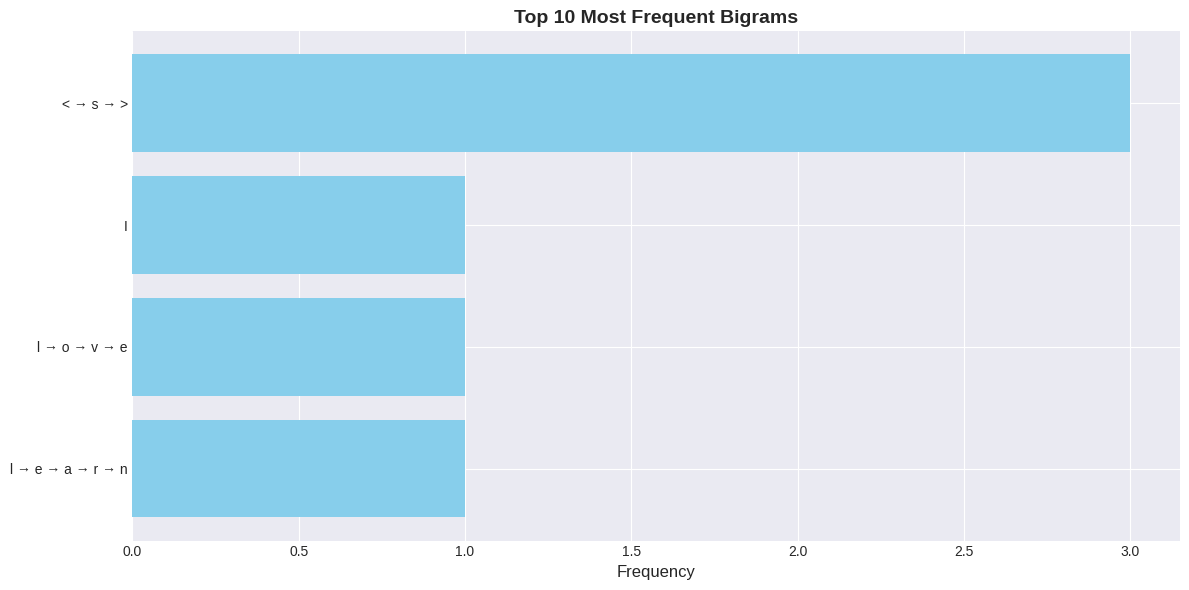

In [32]:
# Visualize bigram frequencies
top_bigrams = all_bigrams[:10]
bigram_labels = [" → ".join(bg[0]) for bg, _ in top_bigrams]
bigram_counts = [count for _, count in top_bigrams]

plt.figure(figsize=(12, 6))
plt.barh(bigram_labels, bigram_counts, color='skyblue')
plt.xlabel('Frequency', fontsize=12)
plt.title('Top 10 Most Frequent Bigrams', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [33]:
# Analyze vocabulary distribution
word_frequencies = Counter()
for sentence in corpus_sentences:
    words = sentence.split()
    word_frequencies.update(words)

print("\nVocabulary Analysis:")
print("=" * 70)
print(f"Total unique words: {len(word_frequencies)}")
print(f"Total word occurrences: {sum(word_frequencies.values())}")

# Frequency distribution
freq_distribution = Counter(word_frequencies.values())
print(f"\nFrequency Distribution:")
print(f"{'Frequency':<15} {'Number of Words':<20}")
print("-" * 35)
for freq in sorted(freq_distribution.keys()):
    count = freq_distribution[freq]
    print(f"{freq:<15} {count:<20}")


Vocabulary Analysis:
Total unique words: 15
Total word occurrences: 21

Frequency Distribution:
Frequency       Number of Words     
-----------------------------------
1               12                  
2               1                   
3               1                   
4               1                   


## 14. Summary Statistics

Comprehensive summary of the autocomplete system we've built.


In [34]:
print("\n" + "=" * 70)
print("AUTOCOMPLETE SYSTEM SUMMARY")
print("=" * 70)

print(f"\nModel Configuration:")
print(f"  N-gram order: {autocomplete.n}")
print(f"  Vocabulary size: {len(autocomplete.vocabulary)}")
print(f"  Smoothing parameter (k): {autocomplete.smoothing_k}")
print(f"  Minimum word frequency: {autocomplete.min_freq}")

print(f"\nModel Statistics:")
print(f"  Unique contexts: {len(autocomplete.model.context_counts)}")
print(f"  Total n-grams: {sum(autocomplete.model.context_counts.values())}")

print(f"\nCapabilities:")
print(f"  ✓ Next word prediction with confidence scores")
print(f"  ✓ Complete sentence generation")
print(f"  ✓ Handles out-of-vocabulary words")
print(f"  ✓ Smoothing for unseen n-grams")
print(f"  ✓ Multiple suggestion strategies (greedy/random)")

print(f"\nApplications:")
print(f"  ✓ Text editors and IDEs")
print(f"  ✓ Search engines")
print(f"  ✓ Mobile keyboards")
print(f"  ✓ Email composition")
print(f"  ✓ Chatbots and dialogue systems")


AUTOCOMPLETE SYSTEM SUMMARY

Model Configuration:
  N-gram order: 3
  Vocabulary size: 18
  Smoothing parameter (k): 0.1
  Minimum word frequency: 1

Model Statistics:
  Unique contexts: 19
  Total n-grams: 26

Capabilities:
  ✓ Next word prediction with confidence scores
  ✓ Complete sentence generation
  ✓ Handles out-of-vocabulary words
  ✓ Smoothing for unseen n-grams
  ✓ Multiple suggestion strategies (greedy/random)

Applications:
  ✓ Text editors and IDEs
  ✓ Search engines
  ✓ Mobile keyboards
  ✓ Email composition
  ✓ Chatbots and dialogue systems


## Key Concepts Demonstrated

This notebook has implemented all core concepts from your Week 3 notes:

1. ✅ **N-gram Fundamentals** - Unigrams, bigrams, trigrams extraction (Section 2)
2. ✅ **Probability Calculations** - MLE and conditional probabilities (Section 3)
3. ✅ **Sequence Probabilities** - Chain rule application (Section 4)
4. ✅ **Sentence Boundaries** - Start/end token handling (Section 5)
5. ✅ **Complete Language Model** - Count and probability matrices (Section 6)
6. ✅ **Model Evaluation** - Perplexity calculation (Section 7)
7. ✅ **OOV Handling** - Unknown word management (Section 8)
8. ✅ **Smoothing** - Add-k Laplace smoothing (Section 9)
9. ✅ **Text Generation** - Sentence creation from learned probabilities
10. ✅ **Autocomplete System** - Practical next-word prediction

---

## Next Steps

Try these exercises to deepen your understanding:

1. Expand the corpus with more diverse sentences
2. Experiment with different n-gram orders (4-grams, 5-grams)
3. Try different smoothing techniques (Kneser-Ney, Good-Turing)
4. Build autocomplete for a specific domain (medical, legal, code)
5. Compare perplexity across different smoothing parameters
6. Implement backoff models (fall back to lower-order n-grams)

**Remember:** N-gram models are the foundation of language modeling. While modern neural models are more sophisticated, the core principles of probability, context, and prediction remain the same!

---

## Week 4 Preview

In Week 4, you'll learn about **Word Embeddings** using the **CBOW (Continuous Bag of Words)** model. You'll see how to represent words as dense vectors that capture semantic meaning - a powerful alternative to the discrete N-gram approach!

**Great work completing Week 3!** 🎉 You've built a working autocomplete system from scratch using statistical language modeling!
